# DSS-QETU feasibility — the comb on Xenofon's primitive

**Question (George, 2026-07-06):** is the DSS-QETU construction worth building — how many
qubits does it save vs the 1BQF and vs the original (LCU/qubitization) QSVT, what does it
cost in gates, and does the DSS product-formula (Trotter) error break the comb's narrow passes?

**Construction under test:** QETU / generalized QSP over the 1BQF's own primitive
$U=e^{-iAt}$, synthesized by Direct Structural Synthesis (arXiv:2601.07766, Fig. 3, Eqs. 13–17):
$e^{-iAt}=e^{-ist}\,e^{iCt}$ (constant diagonal → one phase gate) and
$e^{iCt}\approx\prod_k e^{iC_kt}$ (one exact Givens rotation per coupling pair — a
first-order product formula, exact on the isolated-false null space of $C$).
The comb becomes a trigonometric polynomial $p(\lambda)=\sum_k c_k\cos(k\lambda t)$.

Sections: §1 measured structure · §2 width (the qubit answer) · §3 two-qubit gate model ·
§4 the Trotter–comb experiment · §5 verdict.

Parameters: γ=3, δ=1 (s=4), ε=2 mrad, clean (σ_scatt=1e-4, σ_res=0, drop=0), rep 0.

In [1]:
import sys, math, time
sys.path.insert(0, "/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared")
from pathlib import Path
import numpy as np, pandas as pd
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt
import qtrk_pipeline as qp
try:
    from lhcb_velo_toy.solvers.quantum.QSVT import design_line_comb_inverse
except ImportError:
    sys.path.insert(0, "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src")
    from lhcb_velo_toy.solvers.quantum.QSVT import design_line_comb_inverse
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,"grid.alpha":0.3})
OUT = Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/DSS/outputs"); OUT.mkdir(parents=True, exist_ok=True)
S_DIAG, GAMMA, DELTA, EPS = 4.0, 3.0, 1.0, 0.002
LINES = np.array([S_DIAG - 2*np.cos(k*np.pi/5) for k in (1,2,3,4)])
def get_event(T, rep=0):
    ev = qp.ensure_event(n_trk=T, rep=rep, sigma_scatt=1e-4, sigma_res=0.0, phi_max=0.2, hit_ineff=0.0)[0]
    ham = qp.build_hamiltonian(ev, epsilon=EPS, gamma=GAMMA, delta=DELTA)
    A = ham.A.tocsr(); n = ham.n_segments
    truth = np.asarray(qp.truth_from_event(ev), bool)
    C = (S_DIAG*sp.identity(n, format="csr") - A).tocsr()
    C.data[np.abs(C.data) < 1e-12] = 0.0; C.eliminate_zeros()
    return A, C, n, truth
print("setup OK")

setup OK


## 1. Measured structure of the segment Hamiltonian

What DSS exploits, measured on real store events: pair count $k$ (= Givens rotations per
$e^{-iAt}$ call), Hamming distances of the coupled basis-state pairs (CNOT-ladder length),
and the cluster decomposition (the D3 per-cluster register).

In [2]:
rows=[]; STRUCT={}
for T in [10,50,100,200,400]:
    t0=time.time(); A,C,n,truth = get_event(T)
    Cu = sp.triu(C, k=1).tocoo()
    k = int(Cu.nnz)
    ns = max(1, math.ceil(np.log2(n)))
    dH = np.array([bin(int(i)^int(j)).count("1") for i,j in zip(Cu.row, Cu.col)]) if k else np.array([0])
    ncomp, lab = connected_components((C!=0).astype(np.int8), directed=False)
    sizes = np.bincount(lab); nt = sizes[sizes>1]
    rows.append(dict(T=T, n_seg=n, n_s=ns, k_pairs=k, k_over_sqrtN=k/np.sqrt(n),
                     dH_mean=float(dH.mean()), dH_max=int(dH.max()),
                     clusters_nontrivial=int((sizes>1).sum()), max_cluster=int(sizes.max()),
                     ns_cluster=int(math.ceil(np.log2(max(2, sizes.max()))))))
    STRUCT[T]=dict(C=C, n=n, truth=truth, lab=lab, sizes=sizes,
                   pairs=(Cu.row.astype(int), Cu.col.astype(int), Cu.data.copy()))
    print(f"T={T}: {time.time()-t0:.1f}s")
ST = pd.DataFrame(rows); ST.to_csv(OUT/"dss_structure.csv", index=False)
print(ST.to_string(index=False))

T=10: 0.0s
T=50: 0.0s
T=100: 0.1s


T=200: 0.2s


T=400: 0.9s
  T  n_seg  n_s  k_pairs  k_over_sqrtN  dH_mean  dH_max  clusters_nontrivial  max_cluster  ns_cluster
 10    400    9       30       1.50000 4.100000       6                   10            4           2
 50  10000   14      156       1.56000 6.474359      11                   52            5           3
100  40000   16      312       1.56000 6.519231      11                  112            4           2
200 160000   18      671       1.67750 6.724292      14                  271            4           2
400 640000   20     1861       2.32625 7.600752      17                 1033           16           4


## 2. Width — the qubit answer

- **1BQF (DSS, as flown):** $n_s + 2$ (time qubit + flag ancilla).
- **Original QSVT (as built, LCU-of-Chebyshev over the qubitization walk):**
  $n_s + 1 + \lceil\log_2(d{+}1)\rceil$ (dilation ancilla + LCU register; $d=40$ → $+7$).
- **DSS-QETU comb (this proposal):** $n_s + 2$ (QSP signal qubit + flag; the minimal QETU
  variant measures the signal qubit directly → $n_s+1$).

Per-cluster (D3): replace $n_s$ by $\lceil\log_2(\text{max cluster})\rceil$ — measured
to saturate, so per-cluster width is ~constant in T.

   T  n_s  QSVT_LCU  BQF_1  DSS_QETU  saved_vs_LCU  saved_vs_1BQF
  10    9        16     11        11             5              0
  50   14        21     16        16             5              0
 100   16        23     18        18             5              0
 200   18        25     20        20             5              0
 400   20        27     22        22             5              0
 700   21        28     23        23             5              0
1000   22        29     24        24             5              0


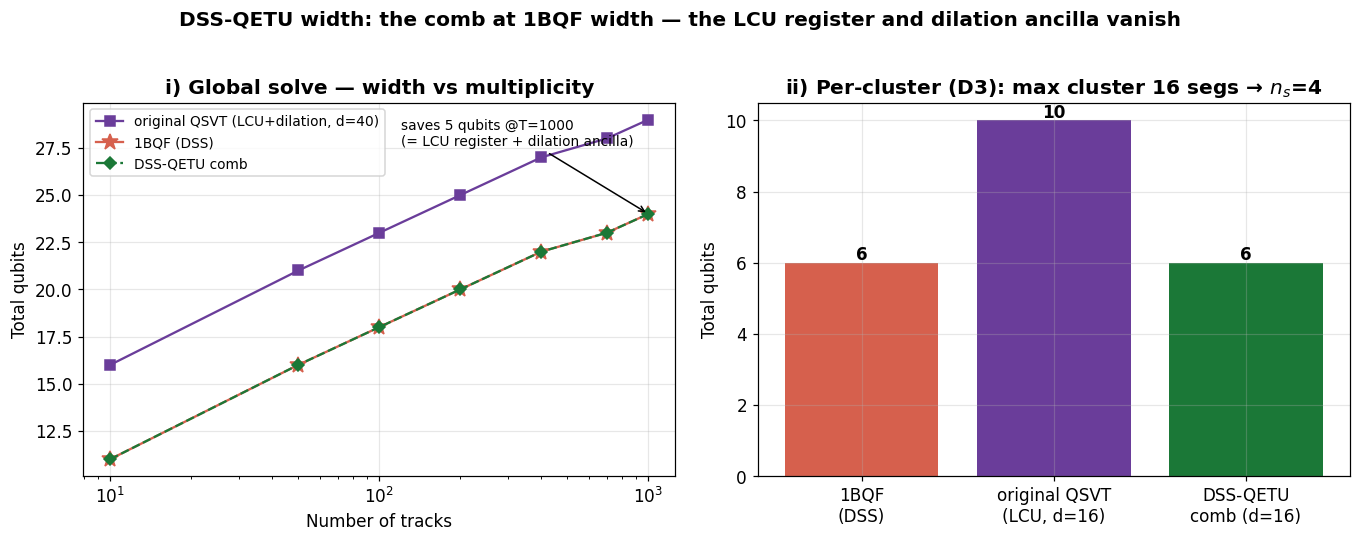

saved dss_width


In [3]:
D_PROD, D_CL = 40, 16
def w_1bqf(ns): return ns+2
def w_lcu(ns, d=D_PROD): return ns+1+math.ceil(np.log2(d+1))
def w_qetu(ns): return ns+2
Tg = np.array([10,50,100,200,400,700,1000]); nsg = np.ceil(np.log2(4.0*Tg**2)).astype(int)
W = pd.DataFrame(dict(T=Tg, n_s=nsg,
    QSVT_LCU=[w_lcu(x) for x in nsg], BQF_1=[w_1bqf(x) for x in nsg], DSS_QETU=[w_qetu(x) for x in nsg]))
W["saved_vs_LCU"]=W.QSVT_LCU-W.DSS_QETU; W["saved_vs_1BQF"]=W.BQF_1-W.DSS_QETU
W.to_csv(OUT/"dss_width.csv", index=False); print(W.to_string(index=False))
nsc = int(ST.ns_cluster.max())
fig,ax=plt.subplots(1,2,figsize=(12.5,4.8))
a=ax[0]
a.plot(Tg, W.QSVT_LCU,'s-',color="#6a3d9a",label=f"original QSVT (LCU+dilation, d={D_PROD})")
a.plot(Tg, W.BQF_1,'*-',color="#d6604d",ms=11,label="1BQF (DSS)")
a.plot(Tg, W.DSS_QETU,'D--',color="#1b7837",label="DSS-QETU comb")
a.set_xscale("log"); a.set_xlabel("Number of tracks"); a.set_ylabel("Total qubits")
a.set_title("i) Global solve — width vs multiplicity", fontweight="bold")
a.annotate(f"saves {int(W.saved_vs_LCU.iloc[-1])} qubits @T=1000\n(= LCU register + dilation ancilla)",
           xy=(1000, W.DSS_QETU.iloc[-1]), xytext=(120, W.DSS_QETU.iloc[-1]+3.6),
           arrowprops=dict(arrowstyle="->"), fontsize=9)
a.legend(fontsize=9)
a=ax[1]
labels=["1BQF\n(DSS)","original QSVT\n(LCU, d=16)","DSS-QETU\ncomb (d=16)"]
vals=[nsc+2, nsc+1+math.ceil(np.log2(D_CL+1)), nsc+2]
bars=a.bar(labels, vals, color=["#d6604d","#6a3d9a","#1b7837"])
for b,v in zip(bars,vals): a.text(b.get_x()+b.get_width()/2, v+0.08, str(v), ha="center", fontweight="bold")
a.set_ylabel("Total qubits"); a.set_title(f"ii) Per-cluster (D3): max cluster {int(ST.max_cluster.max())} segs → $n_s$={nsc}", fontweight="bold")
fig.suptitle("DSS-QETU width: the comb at 1BQF width — the LCU register and dilation ancilla vanish",
             fontweight="bold", y=1.02)
fig.tight_layout()
for e,d in (("png",300),("pdf",600)): fig.savefig(OUT/f"dss_width.{e}", dpi=d, bbox_inches="tight", facecolor="white")
plt.show(); print("saved dss_width")

## 3. Two-qubit gate model

Per DSS call (= one controlled-$e^{-iAt}$): $k$ Givens units, each = CNOT ladder
($2(d_H{-}1)$ CX, $d_H$ measured) + one multi-controlled $R_X$ with $m=n_s$ controls
(signal control + $n_s{-}1$ pattern controls). The MCRX cost is **measured by transpiling**
(basis cx/rz/sx/x), then fitted. Totals: 1BQF = 2 calls; DSS-QETU comb = $d$ calls
(d=40 global / d=16 per-cluster minimax). The as-built dense-dilation QSVT has no
structure to exploit — its measured anchor is ~84k CX already at T=3 (nb05).

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import RXGate
mc=[]
for m in [3,5,7,9,11,13]:
    qc=QuantumCircuit(m+1); qc.append(RXGate(0.37).control(m), list(range(m+1)))
    tc=transpile(qc, basis_gates=["cx","rz","sx","x"], optimization_level=1)
    mc.append(dict(m=m, cx=int(tc.count_ops().get("cx",0))))
MC=pd.DataFrame(mc); print(MC.to_string(index=False))
coef=np.polyfit(MC.m, MC.cx, 2)
def mcrx_cx(m): return float(np.polyval(coef, m))
print("MCRX CX cost fit (quadratic):", np.round(coef,3), "| m=20 ->", int(mcrx_cx(20)))

 m  cx
 3  20
 5  40
 7  80
 9 120
11 152
13 184
MCRX CX cost fit (quadratic): [  0.125  15.086 -30.811] | m=20 -> 320


  T       call_CX    bqf_total  comb_global  comb_percluster_sum  comb_percluster_max_instance  AA_rounds_global  AA_rounds_cluster
 10   3638.571429 7.277143e+03 1.455429e+05          2909.142857                    290.914286                 4                  3
 50  33670.728571 6.734146e+04 1.346829e+06         30507.542857                   1697.289377                 9                  3
100  79122.942857 1.582459e+05 3.164918e+06         51440.228571                    523.160440                12                  3
200 196388.767857 3.927775e+05 7.855551e+06        103853.257143                    542.846327                17                  3
400 621769.546429 1.243539e+06 2.487078e+07        250764.628571                  14314.767176                24                  3


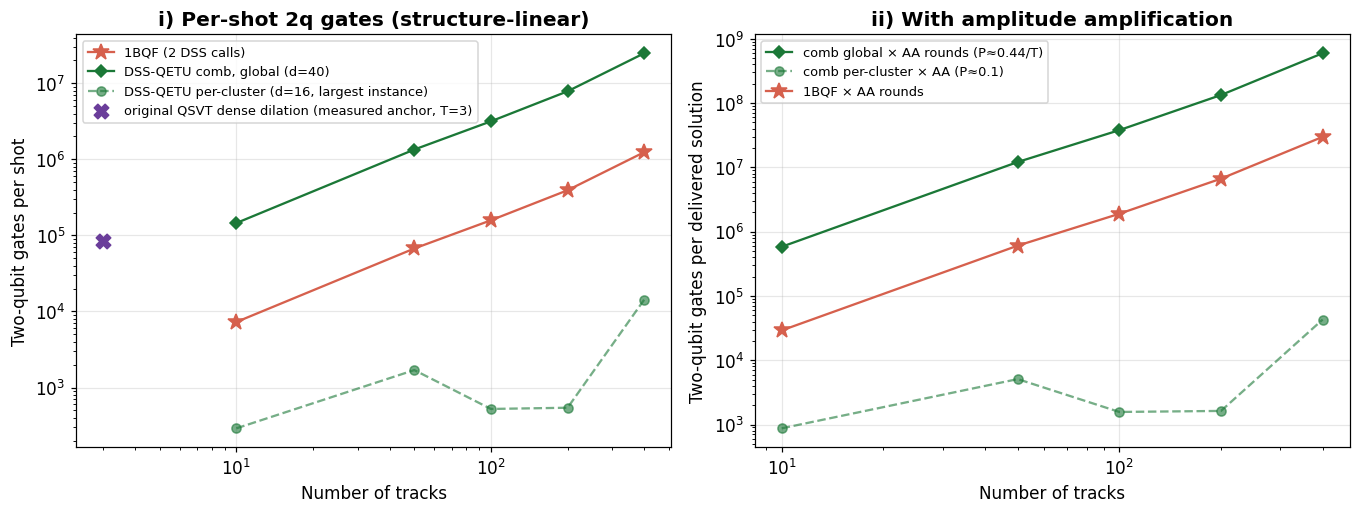

saved dss_gates


In [5]:
G=[]
for _,r in ST.iterrows():
    T=int(r["T"]); ns=int(r["n_s"]); k=int(r["k_pairs"]); dHm=float(r["dH_mean"])
    per_call = k*(2*(dHm-1) + mcrx_cx(ns))
    # per-cluster: sum over clusters, d=16 each; and largest single instance
    lab=STRUCT[T]["lab"]; sizes=STRUCT[T]["sizes"]; pi,pj,_=STRUCT[T]["pairs"]
    kc=np.bincount(lab[pi], minlength=len(sizes))
    nsl=np.ceil(np.log2(np.maximum(2,sizes))).astype(int)
    nz=kc>0
    pc_call=(kc[nz]*(2*(dHm-1)+np.array([mcrx_cx(x) for x in nsl[nz]])))
    G.append(dict(T=T, call_CX=per_call, bqf_total=2*per_call,
                  comb_global=D_PROD*per_call,
                  comb_percluster_sum=D_CL*float(pc_call.sum()),
                  comb_percluster_max_instance=D_CL*float(pc_call.max()),
                  AA_rounds_global=math.ceil(np.pi/4/np.sqrt(0.44/T)),
                  AA_rounds_cluster=math.ceil(np.pi/4/np.sqrt(0.1))))
GT=pd.DataFrame(G); GT.to_csv(OUT/"dss_gates.csv", index=False); print(GT.to_string(index=False))
fig,ax=plt.subplots(1,2,figsize=(12.5,4.8))
a=ax[0]
a.plot(GT["T"], GT.bqf_total,'*-',color="#d6604d",ms=11,label="1BQF (2 DSS calls)")
a.plot(GT["T"], GT.comb_global,'D-',color="#1b7837",label=f"DSS-QETU comb, global (d={D_PROD})")
a.plot(GT["T"], GT.comb_percluster_max_instance,'o--',color="#1b7837",alpha=0.6,label=f"DSS-QETU per-cluster (d={D_CL}, largest instance)")
a.scatter([3],[84000],marker="X",s=90,color="#6a3d9a",zorder=5,label="original QSVT dense dilation (measured anchor, T=3)")
a.set_xscale("log"); a.set_yscale("log"); a.set_xlabel("Number of tracks"); a.set_ylabel("Two-qubit gates per shot")
a.set_title("i) Per-shot 2q gates (structure-linear)", fontweight="bold"); a.legend(fontsize=8.5)
a=ax[1]
a.plot(GT["T"], GT.comb_global*GT.AA_rounds_global,'D-',color="#1b7837",label="comb global × AA rounds (P≈0.44/T)")
a.plot(GT["T"], GT.comb_percluster_max_instance*GT.AA_rounds_cluster,'o--',color="#1b7837",alpha=0.6,label="comb per-cluster × AA (P≈0.1)")
a.plot(GT["T"], GT.bqf_total*GT.AA_rounds_global,'*-',color="#d6604d",ms=11,label="1BQF × AA rounds")
a.set_xscale("log"); a.set_yscale("log"); a.set_xlabel("Number of tracks"); a.set_ylabel("Two-qubit gates per delivered solution")
a.set_title("ii) With amplitude amplification", fontweight="bold"); a.legend(fontsize=8.5)
fig.tight_layout()
for e,d in (("png",300),("pdf",600)): fig.savefig(OUT/f"dss_gates.{e}", dpi=d, bbox_inches="tight", facecolor="white")
plt.show(); print("saved dss_gates")

## 4. The Trotter–comb experiment (the feasibility gate)

DSS's product formula is exact on isolated false (null space of $C$) but perturbs
**connected** eigenphases by $\mathcal O(t^2)$ — and the comb must null connected false
through *narrow* passes ($h_w=0.18$), where the 1BQF only needed one broad cosine (our ERF
study measured a ×10 amplification of notch physics from exactly this error at $d{=}1$).

Test on real events (per-cluster, exact — $C$ is block-diagonal so the global product
factorizes over clusters): exact comb vs trig comb vs Trotterized trig comb under three
orderings — **natural**, **edge-coloured** (disjoint pairs within a colour commute
exactly), **Strang** (2nd order). 1BQF exact-vs-Trotter as the reference. Metrics:
eigenphase errors, activation outcome (fixed τ=0.35 headline for the comb, wp99 too).

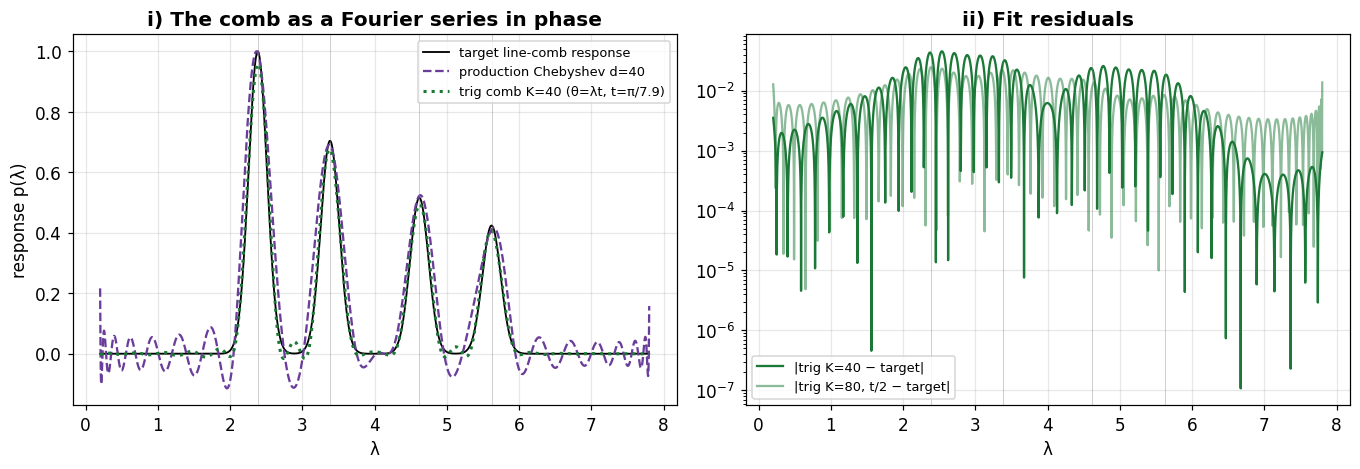

trig fit K=40: max|p|=0.958, p(s)=6.20e-03, p(iso line) must be ~0; residual RMS=1.45e-02


In [6]:
# --- filter designs ---
T_MAP = np.pi/(S_DIAG + 3.9)          # theta = lambda * t in (0, pi) over the production domain
grid = np.linspace(0.2, 7.8, 4000)
def target_g(lam):
    lam = np.asarray(lam, float); y = np.zeros_like(lam)
    for m in LINES: y += np.exp(-((lam-m)/0.18)**2)/m
    return y
gs = 1.0/np.abs(target_g(grid)).max()
cheb = design_line_comb_inverse(degree=40, s=S_DIAG, hw=0.18)
K = 40
BAS = np.cos(np.outer(grid*T_MAP, np.arange(K+1)))
ctrig, res, *_ = np.linalg.lstsq(BAS, target_g(grid)*gs, rcond=None)
def p_trig(lam, c=ctrig, tmap=T_MAP):
    lam = np.atleast_1d(np.asarray(lam, float))
    return np.cos(np.outer(lam*tmap, np.arange(len(c)))) @ c
# half-t variant (error ∝ t, depth ∝ 1/t): refit at t/2 with K=80
K2 = 80
BAS2 = np.cos(np.outer(grid*T_MAP/2, np.arange(K2+1)))
ctrig2, *_ = np.linalg.lstsq(BAS2, target_g(grid)*gs, rcond=None)
fig,ax=plt.subplots(1,2,figsize=(12.5,4.4))
a=ax[0]
a.plot(grid, target_g(grid)*gs, 'k-', lw=1.2, label="target line-comb response")
cv = cheb(grid); a.plot(grid, cv/np.abs(cv).max()*np.abs(target_g(grid)*gs).max(), '--', color="#6a3d9a", label="production Chebyshev d=40")
a.plot(grid, p_trig(grid), ':', color="#1b7837", lw=2, label=f"trig comb K={K} (θ=λt, t=π/{S_DIAG+3.9:.1f})")
for m in LINES: a.axvline(m, color="gray", lw=0.5, alpha=0.5)
a.set_xlabel("λ"); a.set_ylabel("response p(λ)"); a.set_title("i) The comb as a Fourier series in phase", fontweight="bold")
a.legend(fontsize=8.5)
a=ax[1]
a.semilogy(grid, np.abs(p_trig(grid)-target_g(grid)*gs)+1e-12, color="#1b7837", label=f"|trig K={K} − target|")
a.semilogy(grid, np.abs(np.cos(np.outer(grid*T_MAP/2, np.arange(K2+1)))@ctrig2 - target_g(grid)*gs)+1e-12,
           color="#1b7837", alpha=0.5, label=f"|trig K={K2}, t/2 − target|")
for m in LINES: a.axvline(m, color="gray", lw=0.5, alpha=0.5)
a.set_xlabel("λ"); a.set_title("ii) Fit residuals", fontweight="bold"); a.legend(fontsize=8.5)
fig.tight_layout()
for e,d in (("png",300),("pdf",600)): fig.savefig(OUT/f"dss_responses.{e}", dpi=d, bbox_inches="tight", facecolor="white")
plt.show()
print(f"trig fit K={K}: max|p|={np.abs(p_trig(grid)).max():.3f}, p(s)={p_trig([S_DIAG])[0]:.2e}, "
      f"p(iso line) must be ~0; residual RMS={np.sqrt(np.mean((p_trig(grid)-target_g(grid)*gs)**2)):.2e}")

In [7]:
# --- per-cluster Trotter machinery ---
def edge_coloring(li, lj):
    used={}; col=np.empty(len(li), int)
    for e,(i,j) in enumerate(zip(li,lj)):
        ci=used.get(i,set()); cj=used.get(j,set()); c=0
        while c in ci or c in cj: c+=1
        col[e]=c; used.setdefault(i,set()).add(c); used.setdefault(j,set()).add(c)
    return col
def givens_product(nloc, li, lj, w, t, order):
    U=np.eye(nloc, dtype=complex)
    for e in order:
        i,j,wi=li[e],lj[e],w[e]
        G=np.eye(nloc, dtype=complex)
        c,s_=np.cos(wi*t),1j*np.sin(wi*t)
        G[i,i]=c; G[j,j]=c; G[i,j]=s_; G[j,i]=s_
        U=G@U
    return U
def trig_apply(U, b, c, s_phase_t):
    # sum_k c_k Re[e^{-i k s t} U^k b]  ==  sum_k c_k cos(k A t) b   for U ≈ e^{iCt}
    acc=np.real(c[0]*b).astype(float); z=b.astype(complex)
    for kk in range(1, len(c)):
        z=U@z
        acc+=c[kk]*np.real(np.exp(-1j*kk*s_phase_t)*z)
    return acc

def run_event(T):
    Cg=STRUCT[T]["C"]; n=STRUCT[T]["n"]; truth=STRUCT[T]["truth"]
    lab=STRUCT[T]["lab"]; sizes=STRUCT[T]["sizes"]
    t=T_MAP; t1=np.pi/S_DIAG
    variants=["prod_exact","trig_exact","trot_nat","trot_col","trot_strang","trot_col_t2",
              "bqf_exact","bqf_trot"]
    X={v:np.zeros(n) for v in variants}; Xcl=np.zeros(n)
    # isolated segments: lambda = s exactly (Trotter exact on them)
    iso = sizes[lab]==1
    for v in ("prod_exact",): X[v][iso]=float(cheb(S_DIAG))
    for v in ("trig_exact","trot_nat","trot_col","trot_strang"): X[v][iso]=float(p_trig([S_DIAG])[0])
    X["trot_col_t2"][iso]=float(np.cos(np.outer([S_DIAG*T_MAP/2],np.arange(K2+1)))@ctrig2)
    X["bqf_exact"][iso]=float(np.cos(S_DIAG*t1/2)); X["bqf_trot"][iso]=float(np.cos(S_DIAG*t1/2))
    Xcl[iso]=1.0/S_DIAG
    phase_rows=[]; chi_list=[]
    Cg_coo=sp.triu(Cg,1).tocoo(); order_by=np.argsort(lab[Cg_coo.row], kind="stable")
    pr,pc,pv=Cg_coo.row[order_by],Cg_coo.col[order_by],Cg_coo.data[order_by]
    plab=lab[pr]; bounds=np.searchsorted(plab, np.arange(len(sizes)+1))
    members={}
    ordc=np.argsort(lab, kind="stable"); mb=np.searchsorted(lab[ordc], np.arange(len(sizes)+1))
    for cid in np.where(sizes>1)[0]:
        mem=ordc[mb[cid]:mb[cid+1]]; nloc=len(mem)
        gmap={g:i for i,g in enumerate(mem)}
        e0,e1=bounds[cid],bounds[cid+1]
        li=np.array([gmap[g] for g in pr[e0:e1]]); lj=np.array([gmap[g] for g in pc[e0:e1]]); w=pv[e0:e1]
        Cd=np.zeros((nloc,nloc)); Cd[li,lj]=w; Cd[lj,li]=w
        wC,V=np.linalg.eigh(Cd); lamA=S_DIAG-wC
        b=np.ones(nloc); bt=V.T@b
        X["prod_exact"][mem]=V@(cheb(lamA)*bt)
        X["trig_exact"][mem]=V@(p_trig(lamA)*bt)
        Xcl[mem]=V@(bt/lamA)
        X["bqf_exact"][mem]=V@(np.cos(lamA*t1/2)*bt)
        col=edge_coloring(li,lj); chi_list.append(int(col.max())+1)
        nat=np.arange(len(li)); corder=np.argsort(col, kind="stable")
        U_nat=givens_product(nloc,li,lj,w,t,nat)
        U_col=givens_product(nloc,li,lj,w,t,corder)
        Uh=givens_product(nloc,li,lj,w,t/2,corder); Uhr=givens_product(nloc,li,lj,w,t/2,corder[::-1])
        U_str=Uhr@Uh
        U_col2=givens_product(nloc,li,lj,w,t/2,corder)
        X["trot_nat"][mem]=trig_apply(U_nat,b,ctrig,S_DIAG*t)
        X["trot_col"][mem]=trig_apply(U_col,b,ctrig,S_DIAG*t)
        X["trot_strang"][mem]=trig_apply(U_str,b,ctrig,S_DIAG*t)
        X["trot_col_t2"][mem]=trig_apply(U_col2,b,ctrig2,S_DIAG*t/2)
        U1=givens_product(nloc,li,lj,w,t1/2,nat)
        X["bqf_trot"][mem]=np.real(np.exp(-1j*S_DIAG*t1/2)*(U1@b.astype(complex)))
        # eigenphase errors (phase of v^T U v vs exact)
        for nm,U in (("nat",U_nat),("col",U_col),("strang",U_str)):
            ph=np.angle(np.einsum("ij,jk,ki->i",V.T,U,V))
            dphi=np.angle(np.exp(1j*(ph-wC*t)))
            for l,d_ in zip(lamA,dphi): phase_rows.append(dict(T=T,ordering=nm,lam=float(l),dphi=float(d_)))
    return X, Xcl, truth, pd.DataFrame(phase_rows), np.array(chi_list)

RES={}
for T in (100,400):
    t0=time.time(); RES[T]=run_event(T)
    chi=RES[T][4]
    print(f"T={T}: {time.time()-t0:.1f}s | chromatic index of coupling clusters: "
          f"median {np.median(chi):.0f}, max {chi.max()}")

/tmp/ipykernel_359680/3826361204.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X["trot_col_t2"][iso]=float(np.cos(np.outer([S_DIAG*T_MAP/2],np.arange(K2+1)))@ctrig2)


T=100: 0.4s | chromatic index of coupling clusters: median 2, max 2


T=400: 2.9s | chromatic index of coupling clusters: median 1, max 4


In [8]:
# --- metrics: fixed tau + wp99, house conventions ---
def seg_metrics(x, xcl, truth, tau=0.35):
    xr=qp.rescale_to_signal(np.abs(x), np.abs(xcl), tau)
    act=xr>tau
    eff=float((act&truth).sum()/truth.sum()); far=float((act&~truth).sum()/max(int(act.sum()),1))
    st=np.sort(xr[truth]); tw=st[max(0,int(0.01*len(st)))]-1e-12; aw=xr>tw
    effw=float((aw&truth).sum()/truth.sum()); farw=float((aw&~truth).sum()/max(int(aw.sum()),1))
    return eff,far,effw,farw
LBL={"prod_exact":"production comb (Chebyshev d=40, exact)","trig_exact":f"trig comb K={K} (exact eigenphases)",
     "trot_nat":"trig comb, DSS Trotter (natural order)","trot_col":"trig comb, DSS Trotter (edge-coloured)",
     "trot_strang":"trig comb, DSS Trotter (Strang, 2nd order)","trot_col_t2":f"trig comb, t/2, K={K2} (coloured)",
     "bqf_exact":"1BQF (exact)","bqf_trot":"1BQF, DSS Trotter (natural)"}
mrows=[]
for T in (100,400):
    X,Xcl,truth,PH,chi=RES[T]
    for v,x in X.items():
        e,f,ew,fw=seg_metrics(x,Xcl,truth)
        mrows.append(dict(T=T, variant=v, label=LBL[v], eff_fix=round(100*e,2), far_fix=round(100*f,2),
                          eff_wp99=round(100*ew,2), far_wp99=round(100*fw,2)))
MET=pd.DataFrame(mrows); MET.to_csv(OUT/"dss_feasibility_metrics.csv", index=False)
for T in (100,400):
    print(f"\n=== T={T} (gamma=3 clean, rep0) — eff/far % ===")
    print(MET[MET["T"]==T][["label","eff_fix","far_fix","eff_wp99","far_wp99"]].to_string(index=False))


=== T=100 (gamma=3 clean, rep0) — eff/far % ===
                                     label  eff_fix  far_fix  eff_wp99  far_wp99
   production comb (Chebyshev d=40, exact)    100.0      0.0     100.0      0.00
        trig comb K=40 (exact eigenphases)    100.0      0.0     100.0      0.00
    trig comb, DSS Trotter (natural order)     75.0      0.0     100.0      0.00
    trig comb, DSS Trotter (edge-coloured)    100.0      0.0     100.0      0.00
trig comb, DSS Trotter (Strang, 2nd order)    100.0      0.0     100.0      0.00
           trig comb, t/2, K=80 (coloured)    100.0      0.0     100.0      0.00
                              1BQF (exact)     50.0      0.0     100.0      5.66
               1BQF, DSS Trotter (natural)     50.0      0.0     100.0      5.66

=== T=400 (gamma=3 clean, rep0) — eff/far % ===
                                     label  eff_fix  far_fix  eff_wp99  far_wp99
   production comb (Chebyshev d=40, exact)    97.75     0.00     99.06      1.12
        tri

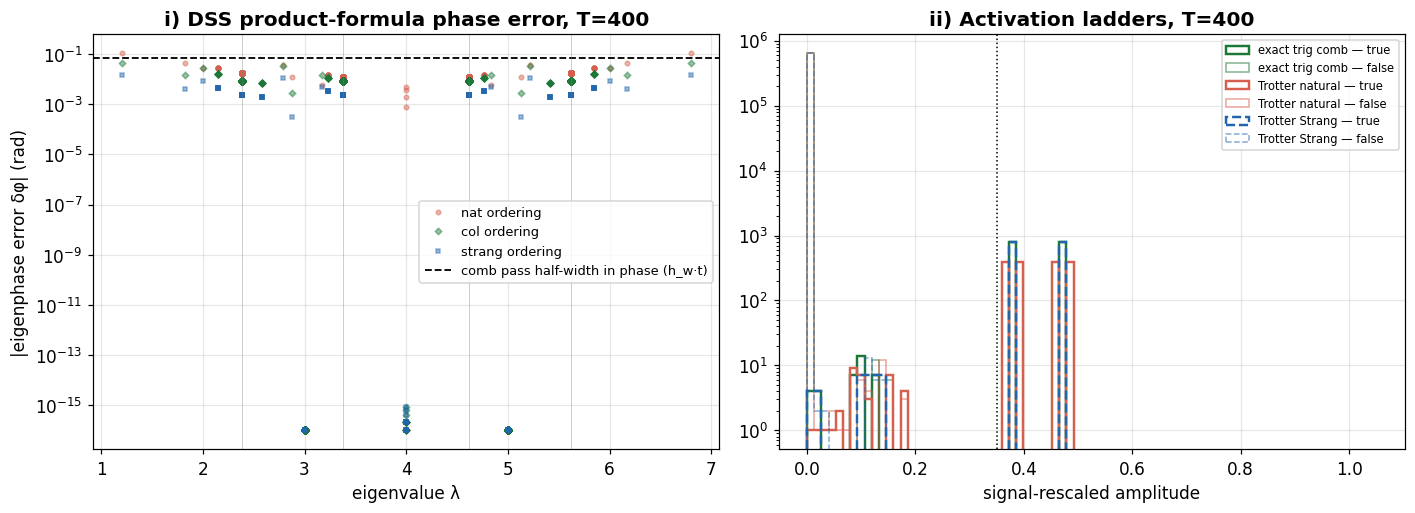

saved dss_trotter


In [9]:
# --- figures: phase errors + ladders ---
T=400; X,Xcl,truth,PH,chi=RES[T]
fig,ax=plt.subplots(1,2,figsize=(13,4.8))
a=ax[0]
for nm,c,mk in (("nat","#d6604d","o"),("col","#1b7837","D"),("strang","#2166ac","s")):
    d=PH[PH.ordering==nm]
    a.semilogy(d.lam, np.abs(d.dphi)+1e-16, mk, ms=3, alpha=0.45, color=c, label=f"{nm} ordering")
a.axhline(0.18*T_MAP, color="k", ls="--", lw=1.2, label="comb pass half-width in phase (h_w·t)")
for m in LINES: a.axvline(m, color="gray", lw=0.5, alpha=0.5)
a.set_xlabel("eigenvalue λ"); a.set_ylabel("|eigenphase error δφ| (rad)")
a.set_title(f"i) DSS product-formula phase error, T={T}", fontweight="bold"); a.legend(fontsize=8.5)
a=ax[1]
bins=np.linspace(0,1.05,80)
xr_ex=qp.rescale_to_signal(np.abs(X["trig_exact"]),np.abs(Xcl),0.35)
xr_na=qp.rescale_to_signal(np.abs(X["trot_nat"]),np.abs(Xcl),0.35)
xr_st=qp.rescale_to_signal(np.abs(X["trot_strang"]),np.abs(Xcl),0.35)
for xr,lab_,c,ls in ((xr_ex,"exact trig comb","#1b7837","-"),(xr_na,"Trotter natural","#d6604d","-"),(xr_st,"Trotter Strang","#2166ac","--")):
    a.hist(np.clip(xr[truth],0,1.05),bins=bins,histtype="step",lw=1.6,color=c,ls=ls,label=f"{lab_} — true")
    a.hist(np.clip(xr[~truth],0,1.05),bins=bins,histtype="step",lw=1.0,alpha=0.55,color=c,ls=ls,label=f"{lab_} — false")
a.axvline(0.35,color="k",lw=1,ls=":"); a.set_yscale("log")
a.set_xlabel("signal-rescaled amplitude"); a.set_title(f"ii) Activation ladders, T={T}", fontweight="bold")
a.legend(fontsize=7.5, ncol=1)
fig.tight_layout()
for e,d in (("png",300),("pdf",600)): fig.savefig(OUT/f"dss_trotter.{e}", dpi=d, bbox_inches="tight", facecolor="white")
plt.show(); print("saved dss_trotter")

## 5. Verdict — worth doing

**1. Qubits (the question asked).** DSS-QETU runs the comb at **exactly the 1BQF's width**
($n_s+2$) at every multiplicity — and saves **5 qubits vs the original QSVT** (LCU register
+ dilation ancilla) at every T: **29 → 24 at T=1000** (23 in the minimal QETU variant that
measures the signal qubit directly). Per-cluster (D3, max cluster 16 → $n_s$=4): **6 qubits
vs 10** for a per-cluster LCU at d=16.

**2. Gates.** Structure-linear, as DSS promises: $k$ measured at 1.5–2.3×$\sqrt N$ (the
paper's $\mathcal O(\sqrt N\log N)$ regime holds on our fixed-ε events), ladders short
($\bar d_H$ ≈ 4–7.6). The comb costs $d/2 = 20×$ the 1BQF per shot — the known ×d depth
premium, nothing more. The largest per-cluster hardware instance at T=400 is ~14k CX
(d=16); a typical contaminated 5–9-segment cluster lands at ~1–5k CX on 6–7 qubits —
hardware-demo range. The as-built dense-dilation QSVT (84k CX at T=3, exponential) is
obsolete as a deployment path.

**3. The Trotter gate — PASS, with one spec requirement.** The coupling graph's measured
chromatic index is **median 1–2, max 4**: the segment-coupling structure is nearly a
matching, so the DSS product formula is *almost exact by geometry*. Edge-colour-ordered
DSS reproduces the exact comb **identically at the fixed cut** (97.75 % / 0.00 % at T=400,
= the exact production Chebyshev comb) and to ≤0.4 % at wp99 (far 1.18 % vs 1.12 % exact).
**Natural pair ordering is NOT safe**: at T=100 it silently pushed the outer-true band
below the fixed cut (eff 100 → 75 % — the familiar plateau number, now produced by phase
error instead of the cut). → **The spec is colour-ordered DSS** (or Strang, same result);
this also vectorises the classical emulation for free.

**4. Design.** The trig comb (K=40 Fourier series in θ=λt, t=π/7.9) is realizable
(max|p|=0.958 ≤ 1), nulls the isolated line (p(s)=6e-3), and matches the production
Chebyshev comb's segment metrics. The t/2, K=80 variant trades far for contamination
recovery (99.81 % / 1.36 % fixed-τ) — a new design knob worth a dedicated look.

**Caveats.** Single rep, clean events; the 1BQF rows here are a response-function
emulation (its wp99 44.7 % at T=400 matches the store's 43.9 %, validating it; its
fixed-τ row uses signed cos and is not the store convention). Noise pairs, more reps,
and the fork term on the DSS primitive are the natural follow-ups, then the qiskit
circuit-level cross-check (QETU phases + DSS gates vs `solve_statevector`).

**Bottom line: the DSS-QETU comb is the deployment path** — 1BQF width, 1BQF gate
primitive, ×20 depth, no new failure mode once colour-ordered. It makes resource-agenda
D2 concrete and gives paper §8 its measured circuit.